# K-Means Clustering

**Dataset elegido:** `Wine` (scikit-learn) – 178 observaciones, 13 variables numéricas (química del vino).  
> Nota: el dataset incluye una etiqueta de clase histórica, pero **NO** la usamos para entrenar (clustering no supervisado). La ocupamos solo al final para una **validación descriptiva**.

## Objetivos del notebook
- Aplicar **mejores prácticas** para K-Means.
- Decidir el número de clusters con **Método del Codo** e **Índice de Silueta**.
- Justificar y aplicar (cuando corresponde) **estandarización** y **PCA**.
- Entrenar el modelo final y crear un **bloque de predicción** para nuevos datos.
- (Opcional) Persistir el pipeline (save/load) para uso productivo.


## 1) Imports y configuración

- Usamos `Pipeline` para **evitar leakage** y asegurar que escalado/modelo se apliquen igual en entrenamiento y predicción.
- Para K-Means, la **estandarización** suele ser necesaria porque el algoritmo usa distancias euclidianas.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

import joblib


## 2) Carga del dataset y vista rápida

K-Means es sensible a escala y outliers; aquí hacemos una inspección básica.


In [2]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y_true = wine.target.copy()  # solo para evaluación descriptiva (no supervisada)

print("Shape X:", X.shape)
display(X.head())
display(X.describe().T)


Shape X: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 3) Preprocesamiento: ¿Estandarización y PCA?

### Estandarización
**Es necesaria** casi siempre en K-Means:
- Si una variable tiene rango mucho mayor, dominará la distancia euclidiana.
- `StandardScaler` centra y escala a varianza unitaria.

### PCA
**Depende del caso**:
- **No es obligatorio** para K-Means.
- Puede ayudar si hay alta correlación entre features o muchas dimensiones.
- Aquí lo usaremos principalmente para **visualización 2D** y, opcionalmente, para entrenar con PCA si se desea.

En este notebook:
- Entrenaremos K-Means sobre datos **escalados** (sin PCA) para mantener interpretabilidad en el espacio original.
- Usaremos PCA(2) para visualizar clusters en 2D.


## 4) Selección de K: Codo + Silueta

### Método del Codo (Inercia)
- Inercia = suma de distancias cuadradas a los centroides.
- Disminuye al aumentar K; buscamos un **punto de inflexión**.

### Silueta
- Mide qué tan bien separadas están las asignaciones ([-1, 1]).
- Valores mayores suelen indicar mejor separación (con cautela: depende de estructura real de datos).

**Buenas prácticas:**
- Evaluar un rango razonable de K (por ejemplo 2..10).
- Fijar `random_state` para reproducibilidad.
- Usar `n_init='auto'` (scikit-learn moderno) para robustez.


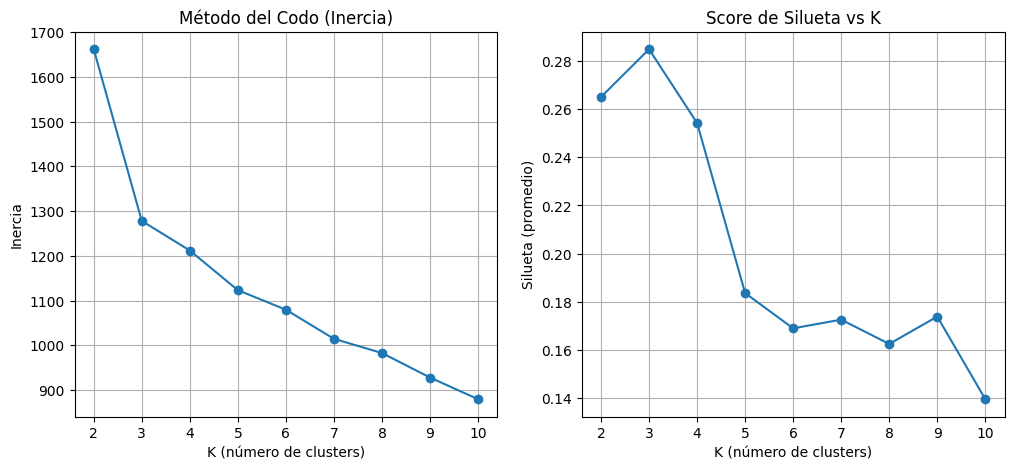

,k,inertia,silhouette
0,2,1661.676117,0.265033
1,3,1277.928489,0.284859
2,4,1211.753113,0.254228
3,5,1123.156547,0.183621
4,6,1079.538509,0.168992
5,7,1014.430909,0.172602
6,8,982.654976,0.162504
7,9,927.956076,0.173874
8,10,879.425701,0.139567


In [3]:
k_values = range(2, 11)

inertias = []
silhouettes = []

# Pipeline de escalado + KMeans (sin PCA) para la selección de K
for k in k_values:
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, n_init="auto", random_state=42))
    ])
    pipe.fit(X)
    labels = pipe.named_steps["kmeans"].labels_
    inertias.append(pipe.named_steps["kmeans"].inertia_)
    silhouettes.append(silhouette_score(pipe.named_steps["scaler"].transform(X), labels))

# --- Gráfico Codo (Inercia) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertias, marker="o")
plt.title("Método del Codo (Inercia)")
plt.xlabel("K (número de clusters)")
plt.ylabel("Inercia")
plt.grid(True)

# --- Gráfico Silueta ---
plt.subplot(1, 2, 2)
plt.plot(list(k_values), silhouettes, marker="o")
plt.title("Score de Silueta vs K")
plt.xlabel("K (número de clusters)")
plt.ylabel("Silueta (promedio)")
plt.grid(True)
plt.show()

# Mostrar tabla resumen
summary = pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouettes})
display(summary)


## 5) Elección de K (criterio práctico)

Regla práctica:
- **Silueta**: tomar el K con mayor silueta (si no es un caso degenerado).
- **Codo**: confirmar que no estemos eligiendo un K innecesariamente alto.

Aquí elegimos:
- `k_best = argmax(silueta)`

> En proyectos reales, complementa con validación de negocio, estabilidad (bootstrapping) y análisis de interpretabilidad por cluster.


In [4]:
k_best = summary.loc[summary["silhouette"].idxmax(), "k"]
k_best = int(k_best)

print("K seleccionado por máxima silueta:", k_best)
summary_sorted = summary.sort_values("silhouette", ascending=False).reset_index(drop=True)
display(summary_sorted.head(5))


K seleccionado por máxima silueta: 3


,k,inertia,silhouette
0,3,1277.928489,0.284859
1,2,1661.676117,0.265033
2,4,1211.753113,0.254228
3,5,1123.156547,0.183621
4,9,927.956076,0.173874


## 6) Entrenamiento final (Pipeline)

Creamos un pipeline productivo:
- `StandardScaler` + `KMeans(k_best)`

Luego:
- Obtenemos etiquetas.
- Resumimos perfiles por cluster (medias).


In [5]:
final_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=k_best, n_init="auto", random_state=42))
])

final_pipe.fit(X)
cluster_labels = final_pipe.named_steps["kmeans"].labels_

X_clustered = X.copy()
X_clustered["cluster"] = cluster_labels

display(X_clustered["cluster"].value_counts().sort_index())

# Perfil promedio por cluster
cluster_profile = X_clustered.groupby("cluster").mean(numeric_only=True)
display(cluster_profile)


cluster
0    65
1    51
2    62
Name: count, dtype: int64

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


## 7) Visualización 2D con PCA (solo para graficar)

Como tenemos 13 dimensiones, proyectamos a 2 componentes para visualizar la separación.
- PCA se ajusta sobre datos **escalados**.
- Graficamos los puntos por cluster.


Varianza explicada PC1+PC2: 0.554 (PC1=0.362, PC2=0.192)


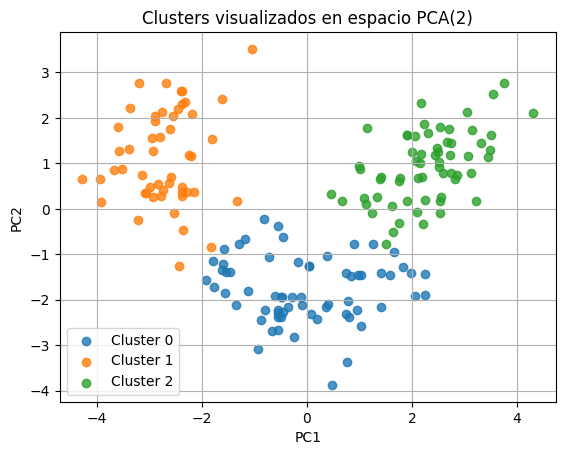

In [6]:
# Transformación escalada
X_scaled = final_pipe.named_steps["scaler"].transform(X)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

explained = pca2.explained_variance_ratio_
print(f"Varianza explicada PC1+PC2: {explained.sum():.3f} (PC1={explained[0]:.3f}, PC2={explained[1]:.3f})")

plt.figure()
for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=f"Cluster {c}", alpha=0.8)

plt.title("Clusters visualizados en espacio PCA(2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend()
plt.show()


## 8) (Opcional) Validación descriptiva usando la etiqueta real

Aunque K-Means es no supervisado, el dataset Wine trae una etiqueta histórica (`target`).  
Aquí solo la usamos para entender si los clusters capturan algo parecido a esas clases.


In [7]:
ct = pd.crosstab(pd.Series(y_true, name="Clase real"), pd.Series(cluster_labels, name="Cluster"))
display(ct)

# Proporciones por clase real
ct_norm = ct.div(ct.sum(axis=1), axis=0)
display(ct_norm)


Cluster,0,1,2
Clase real,,,
0,0,0,59
1,65,3,3
2,0,48,0


Cluster,0,1,2
Clase real,,,
0,0.000000,0.000000,1.000000
1,0.915493,0.042254,0.042254
2,0.000000,1.000000,0.000000


## 9) Bloque de predicción para nuevos datos

### Recomendación productiva
- Guardar un pipeline (escalador + modelo) y reutilizarlo.
- Validar esquema (nombres/orden de columnas) en entrada.
- (Opcional) Devolver distancia al centroide para interpretar “cercanía” al cluster.

Abajo:
- Crear una función `predict_cluster()` para un nuevo registro (dict o DataFrame de 1 fila).
- Mostrar caso de ejemplo (predicción).


In [8]:
feature_names = list(X.columns)

def predict_cluster(pipeline: Pipeline, x_new) -> dict:
    """Predice cluster para un nuevo registro.
    
    Parámetros
    ----------
    pipeline : Pipeline (StandardScaler + KMeans)
    x_new : dict | pd.Series | pd.DataFrame
        - Si es dict/Series: se asume 1 registro con keys=feature_names.
        - Si es DataFrame: se asume 1 fila o varias filas.
    
    Retorna
    -------
    dict con:
    - labels: np.ndarray (clusters)
    - distances: np.ndarray (distancia euclidiana al centroide asignado)
    """
    if isinstance(x_new, (dict, pd.Series)):
        x_df = pd.DataFrame([x_new], columns=feature_names)
    elif isinstance(x_new, pd.DataFrame):
        x_df = x_new.copy()
    else:
        raise TypeError("x_new debe ser dict, Series o DataFrame.")
    
    # Asegurar columnas y orden
    missing = set(feature_names) - set(x_df.columns)
    if missing:
        raise ValueError(f"Faltan columnas: {sorted(missing)}")
    x_df = x_df[feature_names]
    
    scaler = pipeline.named_steps["scaler"]
    kmeans = pipeline.named_steps["kmeans"]
    
    x_scaled = scaler.transform(x_df)
    labels = kmeans.predict(x_scaled)
    
    # Distancia al centroide asignado (por fila)
    centers = kmeans.cluster_centers_
    distances = np.linalg.norm(x_scaled - centers[labels], axis=1)
    
    return {"labels": labels, "distances": distances}

# Ejemplo: tomemos un registro real del dataset (fila 0) como "nuevo"
x_example = X.iloc[0].to_dict()
pred = predict_cluster(final_pipe, x_example)
print("Predicción cluster:", pred["labels"][0])
print("Distancia al centroide:", float(pred["distances"][0]))


Predicción cluster: 2
Distancia al centroide: 2.06344198296232


## 10) Persistencia del modelo (save/load)

Guardamos el pipeline completo con `joblib`.


In [9]:
model_path = "kmeans_wine_pipeline.joblib"
joblib.dump(final_pipe, model_path)

loaded_pipe = joblib.load(model_path)

pred2 = predict_cluster(loaded_pipe, x_example)
assert pred2["labels"][0] == pred["labels"][0]

print("Modelo guardado y recargado OK ->", model_path)


Modelo guardado y recargado OK -> kmeans_wine_pipeline.joblib


## Checklist de mejores prácticas

- ✅ **Estandarización** antes de K-Means (distancias).
- ✅ `Pipeline` para evitar inconsistencias entre entrenamiento y predicción.
- ✅ Selección de K con **codo + silueta** (y criterio práctico).
- ✅ Reproducibilidad (`random_state`).
- ✅ Visualización con **PCA** (para 2D, no obligatorio para entrenar).
- ✅ Bloque de predicción + validación de esquema.
- ✅ Persistencia del pipeline (save/load).

### Siguientes extensiones recomendadas
- Estabilidad de clusters (re-muestreo / bootstrap).
- Comparar con otros algoritmos: GMM, DBSCAN, Agglomerative Clustering.
- Interpretabilidad: variables que más diferencian clusters (ANOVA / SHAP-like para clustering, o perfiles normalizados).


In [10]:
# como reutilizar el pipeline cargado
# loaded_pipe.predict(X_new)
# K-Means clustering en el dataset Palmer Penguins
# Dataset:  
